In [66]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

In [67]:
O_TRAIN  = r"C:\Users\abiga\OneDrive\Desktop\ML\O_Fe_training_data.csv"
O_TEST   = r"C:\Users\abiga\OneDrive\Desktop\ML\O_Fe_TEST_DATA.csv"

NA_TRAIN = r"C:\Users\abiga\OneDrive\Desktop\ML\Na_Fe_training_data.csv"
NA_TEST  = r"C:\Users\abiga\OneDrive\Desktop\ML\Na_Fe_TEST_DATA.csv"

train_o = pd.read_csv(O_TRAIN)
test_o = pd.read_csv(O_TEST)

train_na = pd.read_csv(NA_TRAIN)
test_na = pd.read_csv(NA_TEST)

In [78]:
train_o = train_o.copy()
test_o = test_o.copy()

train_o["FeH_used"] = train_o["Fe/H"].fillna(train_o["Fe/H_o"])
test_o["FeH_used"] = test_o["Fe/H"].fillna(test_o["Fe/H_o"])

cutoffs={'F275W_abs':8.5, 'F336W_abs':6., 'F438W_abs':6., 'F606W_abs':4., 'F814W_abs':3.}

for band, cutoff in cutoffs.items():
    train_o = train_o[train_o[band] <= cutoff]
    test_o = test_o[test_o[band] <= cutoff]

for df in [train_o, test_o]:
    df["c1"] = df["F275W_abs"] - df["F336W_abs"]
    df["c2"] = df["F336W_abs"] - df["F438W_abs"]
    df["c3"] = df["F438W_abs"] - df["F606W_abs"]
    df["c4"] = df["F606W_abs"] - df["F814W_abs"]

feature_cols_o = ["c1", "c2", "c3", "c4", "age_Kruijssen", "FeH_used"]
target_col_o = "O/Fe"

train_o = train_o.dropna(subset=feature_cols_o + [target_col_o])
test_o = test_o.dropna(subset=feature_cols_o + [target_col_o])

In [79]:
train_na = train_na.copy()
test_na = test_na.copy()

train_na["FeH_used"] = train_na["Fe/H"].fillna(train_na["Fe/H_o"])
test_na["FeH_used"] = test_na["Fe/H"].fillna(test_na["Fe/H_o"])

cutoffs={'F275W_abs':8.5, 'F336W_abs':6., 'F438W_abs':6., 'F606W_abs':4., 'F814W_abs':3.}

for band, cutoff in cutoffs.items():
    train_na = train_na[train_na[band] <= cutoff]
    test_na = test_na[test_na[band] <= cutoff]

for df in [train_na, test_na]:
    df["c1"] = df["F275W_abs"] - df["F336W_abs"]
    df["c2"] = df["F336W_abs"] - df["F438W_abs"]
    df["c3"] = df["F438W_abs"] - df["F606W_abs"]
    df["c4"] = df["F606W_abs"] - df["F814W_abs"]

feature_cols_na = ["c1", "c2", "c3", "c4", "age_Kruijssen", "FeH_used"]
target_col_na = "Na/Fe"

train_na = train_na.dropna(subset=feature_cols_na + [target_col_na])
test_na = test_na.dropna(subset=feature_cols_na + [target_col_na])

In [80]:
target_col_o = "O/Fe"

X_train_o = train_o[feature_cols_o]
y_train_o = train_o[target_col_o]

X_test_o = test_o[feature_cols_o]
y_test_o = test_o[target_col_o]


In [81]:
target_col_na = "Na/Fe"

X_train_na = train_na[feature_cols_na]
y_train_na = train_na[target_col_na]

X_test_na = test_na[feature_cols_na]
y_test_na = test_na[target_col_na]


In [82]:
degrees = [1, 2, 3, 4]
alphas = [0.01, 0.1, 1, 10, 100, 1000]

best_rmse_o = float("inf")
best_config_o = None

for d in degrees:
    for a in alphas:
        model = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(-1, 1))),
            ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ("ridge", Ridge(alpha=a))
        ])

        model.fit(X_train_o, y_train_o)
        y_pred_o = model.predict(X_test_o)

        rmse_o = np.sqrt(mean_squared_error(y_test_o, y_pred_o))

        if rmse_o < best_rmse_o:
            best_rmse_o = rmse_o
            best_config_o = (d, a)

print("Best RMSE:", best_rmse_o)
print("Best degree, alpha:", best_config_o)

Best RMSE: 0.20532641613141975
Best degree, alpha: (4, 1)


In [84]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

model_o = Pipeline([
    ("scaler", MinMaxScaler(feature_range=(-1, 1))),
    ("poly", PolynomialFeatures(degree=4, include_bias=False)),
    ("ridge", Ridge(alpha=1))
])

model_o.fit(X_train_o, y_train_o)
y_pred_o = model_o.predict(X_test_o)

rmse_o = np.sqrt(mean_squared_error(y_test_o, y_pred_o))
r2_o = r2_score(y_test_o, y_pred_o)

print("RMSE =", rmse_o)
print("R^2 =", r2_o)

RMSE = 0.20532641613141975
R^2 = 0.425196206901008


In [85]:
degrees = [1, 2, 3, 4]
alphas = [0.01, 0.1, 1, 10, 100, 1000]

best_rmse_na = float("inf")
best_config_na = None

for d in degrees:
    for a in alphas:
        model = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(-1, 1))),
            ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ("ridge", Ridge(alpha=a))
        ])

        model.fit(X_train_na, y_train_na)
        y_pred_na = model.predict(X_test_na)

        rmse_na = np.sqrt(mean_squared_error(y_test_na, y_pred_na))

        if rmse_na < best_rmse_na:
            best_rmse_na = rmse_na
            best_config_na = (d, a)

print("Best RMSE:", best_rmse_na)
print("Best degree, alpha:", best_config_na)

Best RMSE: 0.22174146202623643
Best degree, alpha: (3, 1)


In [86]:
model_na = Pipeline([
    ("scaler", MinMaxScaler(feature_range=(-1, 1))),
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("ridge", Ridge(alpha=1.0))
])

model_na.fit(X_train_na, y_train_na)
y_pred_na = model_na.predict(X_test_na)

rmse_na = np.sqrt(mean_squared_error(y_test_na, y_pred_na))
r2_na = r2_score(y_test_na, y_pred_na)

print("R^2 =", r2_na)
print("RMSE =", rmse_na)

R^2 = 0.4252489486252552
RMSE = 0.22174146202623643


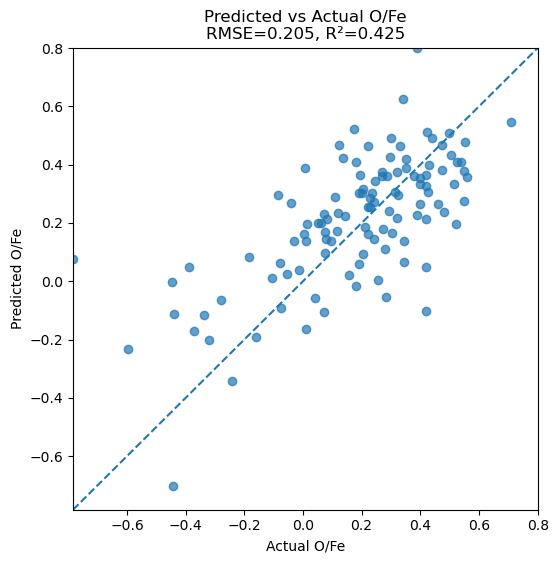

In [87]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_o, y_pred_o, alpha=0.7)

min_val = min(y_test_o.min(), y_pred_o.min())
max_val = max(y_test_o.max(), y_pred_o.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual O/Fe")
plt.ylabel("Predicted O/Fe")
plt.title(f"Predicted vs Actual O/Fe\nRMSE={rmse_o:.3f}, R²={r2_o:.3f}")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.show()

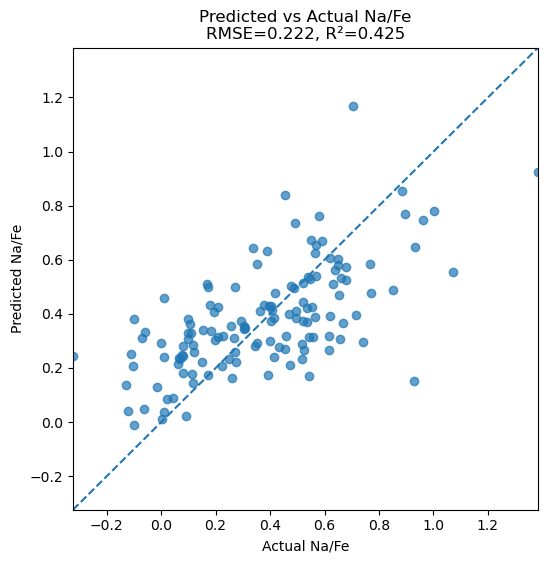

In [88]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_na, y_pred_na, alpha=0.7)

min_val = min(y_test_na.min(), y_pred_na.min())
max_val = max(y_test_na.max(), y_pred_na.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Na/Fe")
plt.ylabel("Predicted Na/Fe")
plt.title(f"Predicted vs Actual Na/Fe\nRMSE={rmse_na:.3f}, R²={r2_na:.3f}")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.show()

In [89]:
poly_o = model_o.named_steps["poly"]
ridge_o = model_o.named_steps["ridge"]

feature_names_o = poly_o.get_feature_names_out(feature_cols_o)

print("Intercept:", ridge_o.intercept_)
for name, coef in zip(feature_names_o, ridge_o.coef_):
    print(name, coef)

Intercept: 0.0987645351033573
c1 0.84106060121448
c2 -0.4982614189370895
c3 -0.12362179938916351
c4 0.3529563770007006
age_Kruijssen 0.16386796135129716
FeH_used -0.0019540660812755535
c1^2 0.3791605174435737
c1 c2 0.22168507962480963
c1 c3 -0.1232551920367621
c1 c4 -0.2853607242120207
c1 age_Kruijssen -0.17955599827511914
c1 FeH_used -0.18330372155011315
c2^2 0.30377969010140055
c2 c3 0.3320841499805384
c2 c4 0.25588228898367743
c2 age_Kruijssen -0.2312562638562784
c2 FeH_used 0.059542918145091134
c3^2 0.13824576653634463
c3 c4 0.10667230905950179
c3 age_Kruijssen -0.017398238054298236
c3 FeH_used -0.04238802969127331
c4^2 -0.13906020219963178
c4 age_Kruijssen -0.022163907403167326
c4 FeH_used 0.10590715909274409
age_Kruijssen^2 -0.19054565746373944
age_Kruijssen FeH_used 0.29645017145370256
FeH_used^2 -0.21708174319725457
c1^3 -0.09326863873499838
c1^2 c2 -0.03495858204243022
c1^2 c3 -0.04709327724989623
c1^2 c4 -0.05638619772947441
c1^2 age_Kruijssen 0.024444329692742957
c1^2 FeH_us

In [90]:
poly_na = model_na.named_steps["poly"]
ridge_na = model_na.named_steps["ridge"]

feature_names_na = poly_na.get_feature_names_out(feature_cols_na)

print("Intercept:", ridge_na.intercept_)
for name, coef in zip(feature_names_na, ridge_na.coef_):
    print(name, coef)

Intercept: 0.5059999769922565
c1 -0.5794967358359501
c2 0.5806023093138609
c3 0.07545956033605662
c4 -0.1020438546700749
age_Kruijssen 0.17541423265918848
FeH_used 0.00715799168887042
c1^2 0.004168730213784855
c1 c2 0.02776777887122442
c1 c3 0.25125569962936095
c1 c4 0.037301159514033774
c1 age_Kruijssen 0.09477848699396287
c1 FeH_used 0.20150454314550453
c2^2 -0.4283748599496626
c2 c3 -0.32173657450690085
c2 c4 -0.29660487269130087
c2 age_Kruijssen -0.11918619685424754
c2 FeH_used 0.2726996321987877
c3^2 -0.07648047155200378
c3 c4 0.03096872605958779
c3 age_Kruijssen 0.25255206702747945
c3 FeH_used -0.09743984962248156
c4^2 0.181339212357824
c4 age_Kruijssen 0.29406748986535136
c4 FeH_used -0.22846287461418896
age_Kruijssen^2 -0.03470063484043401
age_Kruijssen FeH_used -0.09580851474466504
FeH_used^2 0.1575135415996806
c1^3 -0.15514138757893936
c1^2 c2 -0.1192431932425588
c1^2 c3 -0.08344387554759387
c1^2 c4 -0.10571079661195135
c1^2 age_Kruijssen -0.05142967178896503
c1^2 FeH_used 0.